# Random Forest Out-of-Bag (OOB) Error Convergence

Random Forest classifiers leverage bagging (bootstrap aggregation). Since each tree is trained on a bootstrap sample of the data, approximately 36.8% of samples are left out (Out-of-Bag). These OOB samples act as a built-in validation set to evaluate classification error rates dynamically without requiring a separate test set. This notebook fits a Random Forest classifier across tree count scales and plots the OOB error decay.



In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier
from sklearn.datasets import make_classification

# Generate synthetic classification coordinates (600 samples, 10 features)
np.random.seed(210)
X, y = make_classification(
    n_samples=600, 
    n_features=10, 
    n_informative=6, 
    n_classes=2, 
    random_state=42
)

df_rf = pd.DataFrame(X, columns=[f"Feat_{i+1:02d}" for i in range(10)])
df_rf['Target'] = y
df_rf.head(10)



,Feat_01,Feat_02,Feat_03,Feat_04,Feat_05,Feat_06,Feat_07,Feat_08,Feat_09,Feat_10,Target
0,1.545189,-1.183438,1.007157,-1.571718,0.517995,-5.910735,-2.900631,1.749806,-2.284907,-0.118728,1
1,0.255626,2.250859,-0.005560,-1.224287,1.178513,-1.920757,0.088674,-2.286544,-2.791662,2.190843,1
2,4.887628,1.458527,0.587392,4.679592,1.414187,5.845393,0.350709,-4.272633,0.839983,2.487371,1
3,5.155678,-1.800339,-0.782003,1.365058,-0.759703,-4.925046,-3.166671,1.197874,-3.050253,2.324277,0
4,-0.520443,1.533960,-1.217283,1.306284,0.159463,2.052248,-0.390630,0.488834,0.518429,-3.758231,0
5,2.103268,1.383202,-1.176173,4.071836,0.487560,2.212480,-0.443307,3.583661,-0.984670,0.242247,0
6,3.548838,-0.907569,-0.863494,0.515179,-0.031203,-3.404138,-3.066491,-1.001207,-1.651793,-1.347715,0
7,-1.067348,0.816916,-0.868261,-2.816283,0.097813,-3.815431,-3.000692,3.680193,-0.139059,-1.817763,1
8,-1.658795,0.002814,-1.500222,0.767350,-0.778837,0.335735,1.519285,1.984179,-0.862150,-0.459699,1
9,1.255772,-0.395534,-0.016610,-1.280915,-0.105819,-5.683590,-1.676524,-0.755103,-3.737994,-0.229094,0


## Out-of-Bag (OOB) Errors Iterative Search

We fit Random Forests with tree counts ranging from 15 to 250 trees, specifying `oob_score=True`, and record the validation error rates.



In [2]:
# Trace OOB error rates across tree count ranges
tree_ranges = range(15, 251, 5)
oob_errors = []

for n_trees in tree_ranges:
    # Train Random Forest
    rf = RandomForestClassifier(
        n_estimators=n_trees,
        min_samples_leaf=4,
        oob_score=True,
        warm_start=False,
        random_state=42
    )
    rf.fit(X, y)
    
    # OOB Error = 1 - OOB Score
    oob_error = 1.0 - rf.oob_score_
    oob_errors.append(oob_error)

print(f"Initial OOB Error (15 trees): {oob_errors[0]:.4f}")
print(f"Final Stable OOB Error (250 trees): {oob_errors[-1]:.4f}")



Initial OOB Error (15 trees): 0.1233
Final Stable OOB Error (250 trees): 0.1067


C:\Users\hp\miniconda3\Lib\site-packages\sklearn\ensemble\_forest.py:589: UserWarning:

Some inputs do not have OOB scores. This probably means too few trees were used to compute any reliable OOB estimates.



## OOB Error Decay Convergence Plot

Using Matplotlib, we chart the OOB error rate against the number of trees to highlight where the bagging ensemble stabilizes (OOB Stability Epoch).



<cell>:11: UserWarning:

FigureCanvasAgg is non-interactive, and thus cannot be shown



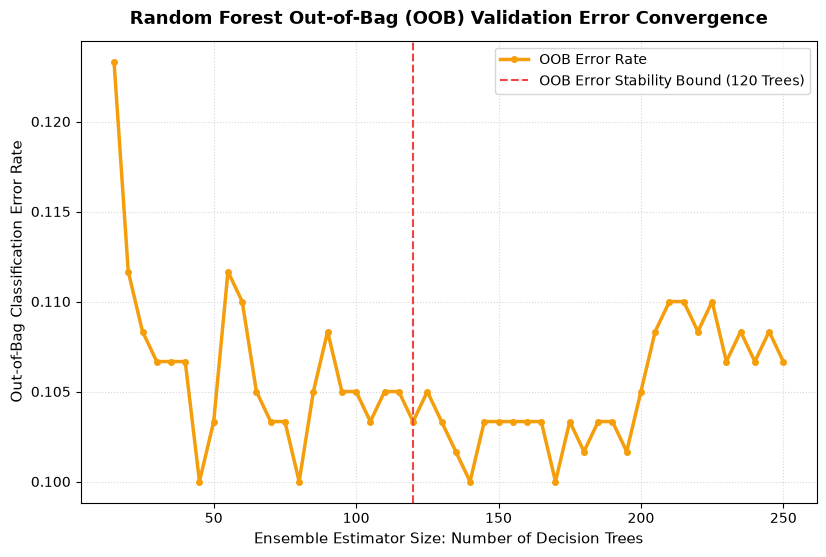

In [3]:
plt.figure(figsize=(9.5, 6))

plt.plot(tree_ranges, oob_errors, color='#F59E0B', linewidth=2.5, marker='o', markersize=4, label='OOB Error Rate')
plt.axvline(120, color='#EF4444', linestyle='--', linewidth=1.5, label='OOB Error Stability Bound (120 Trees)')

plt.title('Random Forest Out-of-Bag (OOB) Validation Error Convergence', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Ensemble Estimator Size: Number of Decision Trees', fontsize=11)
plt.ylabel('Out-of-Bag Classification Error Rate', fontsize=11)
plt.legend()
plt.grid(True, linestyle=':', alpha=0.5)
plt.show()
